ridge regression方程如下：

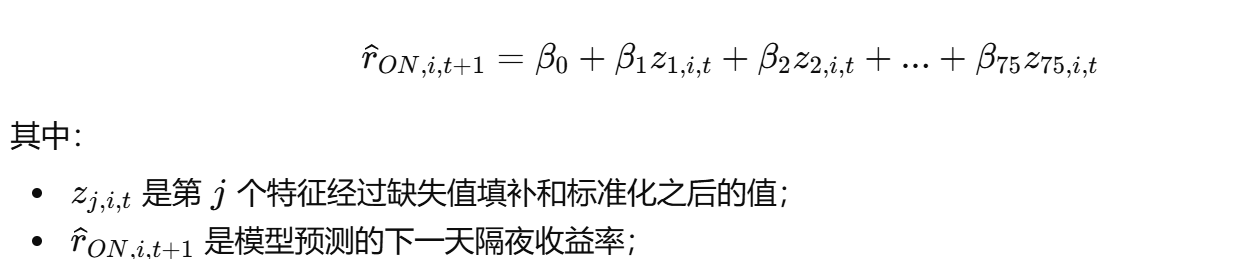

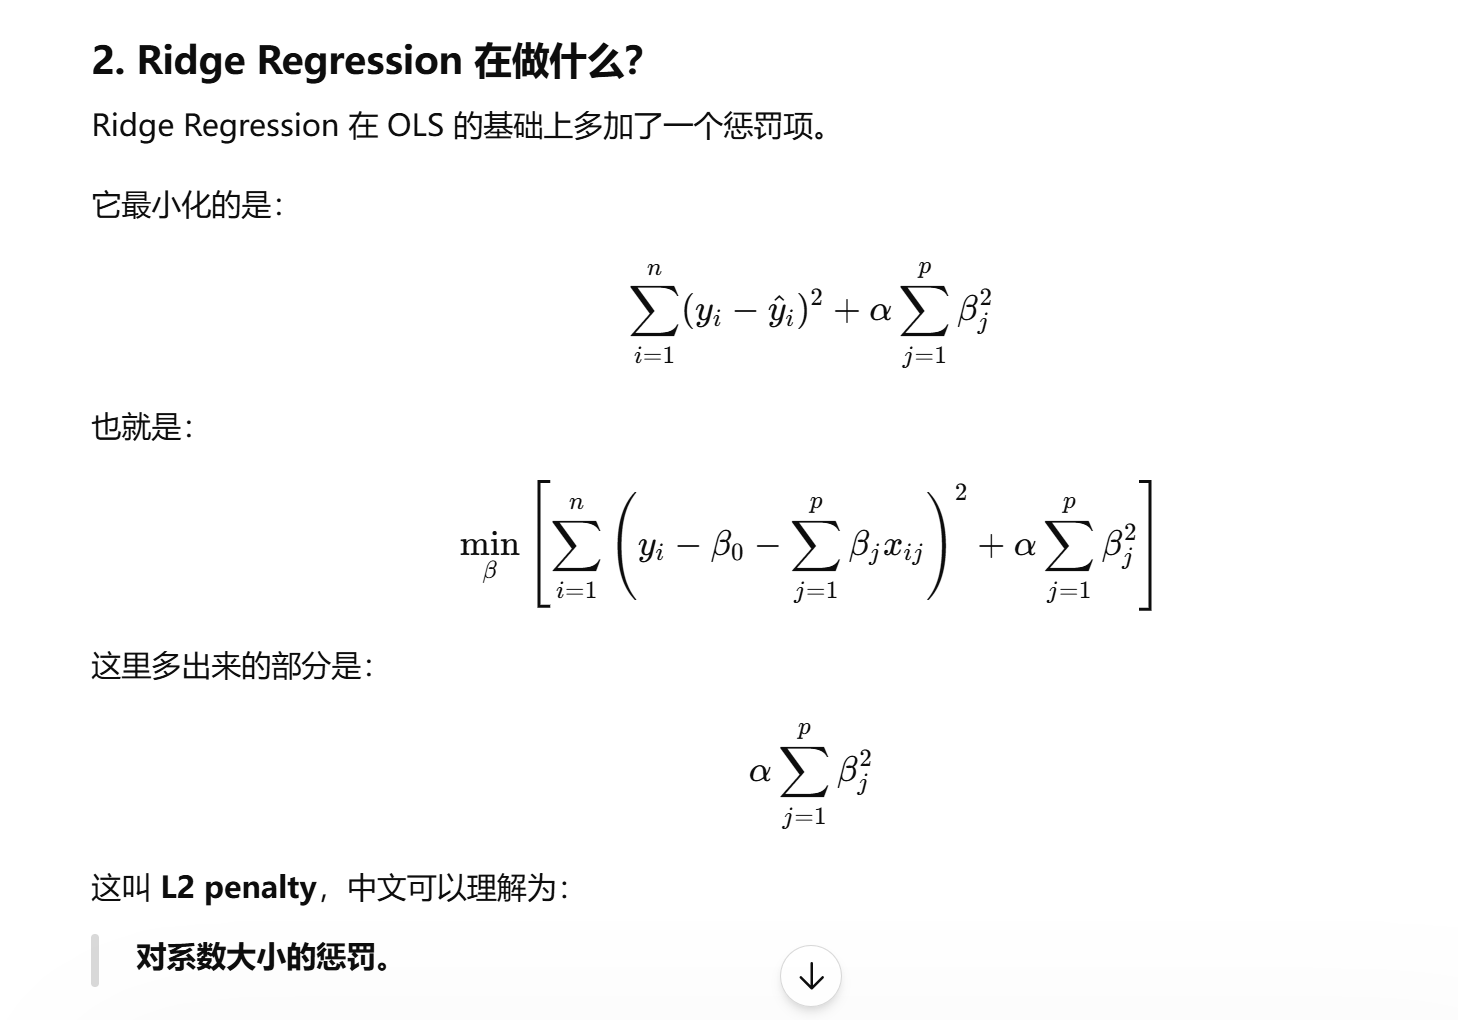

在代码中对α参数的设置为：先测试了一组候选值：[0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]

然后根据 validation set 上的 mean daily Rank IC 最大 这个标准，最终选择了：best_alpha = 10000.0

In [2]:
# ============================================================
# Ridge Regression for predicting next-day overnight return
# Input file:
#   stage4_final_75_features_panel.parquet
#
# Output folder:
#   Bridge Regression Predictions
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ============================================================
# 1. Set file path and output folder
# ============================================================

from pathlib import Path
import os

FILE_NAME = "stage4_final_75_features_panel.parquet"

print("Current working directory:")
print(os.getcwd())

possible_paths = [
    Path(FILE_NAME),
    Path("MLF_coursework") / FILE_NAME,
    Path("..") / FILE_NAME,
    Path("..") / "MLF_coursework" / FILE_NAME,
]

DATA_PATH = None

for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    candidates = list(Path.cwd().rglob(FILE_NAME))
    
    if len(candidates) > 0:
        DATA_PATH = candidates[0]
    else:
        raise FileNotFoundError(
            f"找不到 {FILE_NAME}。\n"
            f"当前运行目录是：{os.getcwd()}\n"
            "请确认 notebook 是否在 MLF_coursework 文件夹内运行。"
        )

print("Using data file:", DATA_PATH)


# ============================================================
# 2. Load data
# ============================================================

df = pd.read_parquet(DATA_PATH, engine="pyarrow")

print("Original data shape:", df.shape)
print("Number of columns:", len(df.columns))


# ============================================================
# 3. Basic cleaning
# ============================================================

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])

# 只保留 eligible universe
if "is_trade_eligible" in df.columns:
    before = len(df)

    if df["is_trade_eligible"].dtype == bool:
        eligible_mask = df["is_trade_eligible"]
    else:
        eligible_mask = pd.to_numeric(
            df["is_trade_eligible"], errors="coerce"
        ).fillna(0).eq(1)

    df = df.loc[eligible_mask].copy()
    after = len(df)

    print(f"Filtered by is_trade_eligible: {before:,} -> {after:,}")

# 排序
sort_cols = [c for c in ["date", "ticker"] if c in df.columns]
if len(sort_cols) > 0:
    df = df.sort_values(sort_cols).reset_index(drop=True)


# ============================================================
# 4. Choose target variable
# ============================================================

if "target_r_on_next_winsor" in df.columns:
    TARGET_COL = "target_r_on_next_winsor"
elif "target_r_on_next" in df.columns:
    TARGET_COL = "target_r_on_next"
else:
    raise ValueError(
        "数据里找不到 target_r_on_next_winsor 或 target_r_on_next。"
    )

print("Target variable:", TARGET_COL)

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df = df.loc[df[TARGET_COL].notna()].copy()

print("Data shape after dropping missing target:", df.shape)


# ============================================================
# 5. Identify feature columns
# ============================================================

exclude_cols = {
    "date",
    "ticker",
    "instrument_id",
    "is_trade_eligible",
    "sample_split",
    "target_r_on_next",
    "target_r_on_next_winsor",
}

candidate_feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
]

feature_cols = [
    c for c in candidate_feature_cols
    if pd.api.types.is_numeric_dtype(df[c])
]

print("Initial numeric feature count:", len(feature_cols))

# 转换为 float32，节省内存
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float32")

df[TARGET_COL] = df[TARGET_COL].astype("float32")

# 删除几乎全是缺失值的特征
na_ratio = df[feature_cols].isna().mean()
feature_cols = [
    c for c in feature_cols
    if na_ratio[c] < 0.99
]

# 删除常数特征
nunique = df[feature_cols].nunique(dropna=True)
feature_cols = [
    c for c in feature_cols
    if nunique[c] > 1
]

print("Final number of features used in Ridge:", len(feature_cols))

feature_list_df = pd.DataFrame({
    "feature_number": range(1, len(feature_cols) + 1),
    "feature_name": feature_cols,
})

feature_list_df.to_csv(
    OUTPUT_DIR / "ridge_feature_list_used.csv",
    index=False
)


# ============================================================
# 6. Prepare train / validation / test split
# ============================================================

def normalize_split_name(x):
    x = str(x).lower().strip()

    if x in ["train", "training"]:
        return "train"

    if x in ["valid", "validation", "val"]:
        return "validation"

    if x in ["test", "testing"]:
        return "test"

    return x


if "sample_split" in df.columns:
    df["_split_used"] = df["sample_split"].apply(normalize_split_name)
else:
    df["_split_used"] = np.nan

train_mask = df["_split_used"].eq("train")
valid_mask = df["_split_used"].eq("validation")
test_mask = df["_split_used"].eq("test")

# 如果没有 sample_split，就按时间自动切分
if train_mask.sum() == 0 or valid_mask.sum() == 0:
    print("sample_split 里没有可识别的 train / validation，开始按日期自动切分。")

    if "date" not in df.columns:
        raise ValueError("没有 sample_split，也没有 date，无法自动按时间切分。")

    unique_dates = np.array(sorted(df["date"].dropna().unique()))
    n_dates = len(unique_dates)

    train_end = int(n_dates * 0.70)
    valid_end = int(n_dates * 0.85)

    train_dates = set(unique_dates[:train_end])
    valid_dates = set(unique_dates[train_end:valid_end])
    test_dates = set(unique_dates[valid_end:])

    df["_split_used"] = np.where(
        df["date"].isin(train_dates), "train",
        np.where(df["date"].isin(valid_dates), "validation", "test")
    )

    train_mask = df["_split_used"].eq("train")
    valid_mask = df["_split_used"].eq("validation")
    test_mask = df["_split_used"].eq("test")

print("\nSplit counts:")
print(df["_split_used"].value_counts(dropna=False))

split_summary_df = (
    df["_split_used"]
    .value_counts(dropna=False)
    .rename_axis("split")
    .reset_index(name="n_obs")
)

split_summary_df.to_csv(
    OUTPUT_DIR / "ridge_split_summary.csv",
    index=False
)

if train_mask.sum() == 0:
    raise ValueError("训练集为空。")

if valid_mask.sum() == 0:
    raise ValueError("验证集为空。")


# ============================================================
# 7. Evaluation functions
# ============================================================

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "n_obs": len(y_true),
    }


def make_prediction_frame(base_df, predictions, target_col):
    id_cols = [
        c for c in [
            "date",
            "ticker",
            "instrument_id",
            "sample_split",
            "_split_used"
        ]
        if c in base_df.columns
    ]

    keep_cols = list(dict.fromkeys(id_cols + [target_col]))

    out = base_df[keep_cols].copy()

    # Ridge 预测出来的隔夜收益率
    out["ridge_pred_return"] = predictions.astype("float32")

    # 对于作业来说，这个可以直接作为股票打分
    out["ridge_score"] = out["ridge_pred_return"]

    return out


def daily_rank_ic(pred_df, pred_col, target_col):
    if "date" not in pred_df.columns:
        return pd.DataFrame()

    rows = []

    for d, g in pred_df.groupby("date", observed=True):
        g = g[[pred_col, target_col]].dropna()

        if len(g) < 5:
            continue

        if g[pred_col].nunique() <= 1:
            continue

        if g[target_col].nunique() <= 1:
            continue

        ic = g[pred_col].rank().corr(g[target_col].rank())

        rows.append({
            "date": d,
            "rank_ic": ic,
            "n_stocks": len(g),
        })

    return pd.DataFrame(rows)


def daily_gross_long_short_return(
    pred_df,
    pred_col,
    target_col,
    q=0.10,
):
    if "date" not in pred_df.columns:
        return pd.DataFrame()

    rows = []

    for d, g in pred_df.groupby("date", observed=True):
        g = g[[pred_col, target_col]].dropna()

        n = len(g)
        k = int(np.floor(n * q))

        if n < 20 or k < 1:
            continue

        g = g.sort_values(pred_col)

        short_ret = g.head(k)[target_col].mean()
        long_ret = g.tail(k)[target_col].mean()
        ls_ret = long_ret - short_ret

        rows.append({
            "date": d,
            "long_mean_return": long_ret,
            "short_mean_return": short_ret,
            "gross_long_short_return": ls_ret,
            "n_long": k,
            "n_short": k,
        })

    return pd.DataFrame(rows)


def safe_annualized_ratio(mean_value, std_value):
    if std_value is None:
        return np.nan

    if not np.isfinite(std_value):
        return np.nan

    if std_value == 0:
        return np.nan

    return mean_value / std_value * np.sqrt(252)


def evaluate_prediction_frame(pred_df, split_name, target_col):
    y_true = pred_df[target_col].values
    y_pred = pred_df["ridge_pred_return"].values

    metrics = regression_metrics(y_true, y_pred)
    metrics["split"] = split_name

    ic_df = daily_rank_ic(
        pred_df,
        pred_col="ridge_score",
        target_col=target_col
    )

    if len(ic_df) > 0:
        ic_mean = ic_df["rank_ic"].mean()
        ic_std = ic_df["rank_ic"].std()

        metrics["mean_daily_rank_ic"] = ic_mean
        metrics["std_daily_rank_ic"] = ic_std
        metrics["rank_ic_ir_annualized"] = safe_annualized_ratio(ic_mean, ic_std)

    else:
        metrics["mean_daily_rank_ic"] = np.nan
        metrics["std_daily_rank_ic"] = np.nan
        metrics["rank_ic_ir_annualized"] = np.nan

    ls_df = daily_gross_long_short_return(
        pred_df,
        pred_col="ridge_score",
        target_col=target_col,
        q=0.10,
    )

    if len(ls_df) > 0:
        ls_mean = ls_df["gross_long_short_return"].mean()
        ls_std = ls_df["gross_long_short_return"].std()

        metrics["gross_ls_daily_mean"] = ls_mean
        metrics["gross_ls_daily_std"] = ls_std
        metrics["gross_ls_sharpe_annualized"] = safe_annualized_ratio(ls_mean, ls_std)

    else:
        metrics["gross_ls_daily_mean"] = np.nan
        metrics["gross_ls_daily_std"] = np.nan
        metrics["gross_ls_sharpe_annualized"] = np.nan

    return metrics, ic_df, ls_df


# ============================================================
# 8. Build Ridge model
# ============================================================

def build_ridge_model(alpha):
    model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=alpha, fit_intercept=True))
        ]
    )

    return model


# ============================================================
# 9. Prepare X and y
# ============================================================

X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, TARGET_COL].values

X_valid = df.loc[valid_mask, feature_cols]
y_valid = df.loc[valid_mask, TARGET_COL].values

print("\nTraining set shape:", X_train.shape)
print("Validation set shape:", X_valid.shape)

if test_mask.sum() > 0:
    X_test = df.loc[test_mask, feature_cols]
    y_test = df.loc[test_mask, TARGET_COL].values
    print("Test set shape:", X_test.shape)
else:
    X_test = None
    y_test = None
    print("No test set found.")


# ============================================================
# 10. Tune Ridge alpha on validation set
# ============================================================

alpha_grid = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
    1000.0,
    10000.0,
]

tuning_results = []

for alpha in alpha_grid:
    print(f"\nFitting Ridge alpha = {alpha}")

    model = build_ridge_model(alpha)
    model.fit(X_train, y_train)

    valid_pred = model.predict(X_valid)

    valid_pred_df_temp = make_prediction_frame(
        df.loc[valid_mask],
        valid_pred,
        target_col=TARGET_COL
    )

    metrics, _, _ = evaluate_prediction_frame(
        valid_pred_df_temp,
        split_name="validation",
        target_col=TARGET_COL
    )

    metrics["alpha"] = alpha
    tuning_results.append(metrics)

    print(
        f"alpha={alpha} | "
        f"RMSE={metrics['rmse']:.8f} | "
        f"MAE={metrics['mae']:.8f} | "
        f"R2={metrics['r2']:.8f} | "
        f"RankIC={metrics['mean_daily_rank_ic']:.6f} | "
        f"Gross LS Sharpe={metrics['gross_ls_sharpe_annualized']:.4f}"
    )


tuning_df = pd.DataFrame(tuning_results)

# 这个作业更看重横截面排序，所以优先按 validation Rank IC 选择 alpha
tuning_df["selection_rank_ic"] = tuning_df["mean_daily_rank_ic"].fillna(-999)

tuning_df = tuning_df.sort_values(
    by=["selection_rank_ic", "rmse"],
    ascending=[False, True]
).reset_index(drop=True)

best_alpha = float(tuning_df.loc[0, "alpha"])

print("\nBest alpha selected by validation Rank IC:")
print(best_alpha)

tuning_df.to_csv(
    OUTPUT_DIR / "ridge_alpha_tuning_results.csv",
    index=False
)


# ============================================================
# 11. Refit best model on train only and evaluate validation
# ============================================================

best_model_train_only = build_ridge_model(best_alpha)
best_model_train_only.fit(X_train, y_train)

valid_pred = best_model_train_only.predict(X_valid)

valid_pred_df = make_prediction_frame(
    df.loc[valid_mask],
    valid_pred,
    target_col=TARGET_COL
)

valid_pred_df["model_training_window"] = "train_only"

valid_metrics, valid_ic_df, valid_ls_df = evaluate_prediction_frame(
    valid_pred_df,
    split_name="validation",
    target_col=TARGET_COL
)

valid_pred_df.to_parquet(
    OUTPUT_DIR / "ridge_validation_predictions.parquet",
    index=False
)

valid_ic_df.to_csv(
    OUTPUT_DIR / "ridge_validation_daily_rank_ic.csv",
    index=False
)

valid_ls_df.to_csv(
    OUTPUT_DIR / "ridge_validation_daily_gross_long_short.csv",
    index=False
)

joblib.dump(
    best_model_train_only,
    OUTPUT_DIR / "ridge_model_train_only.pkl"
)


# ============================================================
# 12. Refit final model on train + validation and evaluate test
# ============================================================

train_valid_mask = train_mask | valid_mask

X_train_valid = df.loc[train_valid_mask, feature_cols]
y_train_valid = df.loc[train_valid_mask, TARGET_COL].values

final_model = build_ridge_model(best_alpha)
final_model.fit(X_train_valid, y_train_valid)

joblib.dump(
    final_model,
    OUTPUT_DIR / "ridge_final_model.pkl"
)

all_metrics = [valid_metrics]
oos_prediction_frames = [valid_pred_df]

if test_mask.sum() > 0:
    test_pred = final_model.predict(X_test)

    test_pred_df = make_prediction_frame(
        df.loc[test_mask],
        test_pred,
        target_col=TARGET_COL
    )

    test_pred_df["model_training_window"] = "train_plus_validation"

    test_metrics, test_ic_df, test_ls_df = evaluate_prediction_frame(
        test_pred_df,
        split_name="test",
        target_col=TARGET_COL
    )

    all_metrics.append(test_metrics)
    oos_prediction_frames.append(test_pred_df)

    test_pred_df.to_parquet(
        OUTPUT_DIR / "ridge_test_predictions.parquet",
        index=False
    )

    test_ic_df.to_csv(
        OUTPUT_DIR / "ridge_test_daily_rank_ic.csv",
        index=False
    )

    test_ls_df.to_csv(
        OUTPUT_DIR / "ridge_test_daily_gross_long_short.csv",
        index=False
    )


# ============================================================
# 13. Save all out-of-sample predictions and metrics
# ============================================================

metrics_df = pd.DataFrame(all_metrics)

metrics_df.to_csv(
    OUTPUT_DIR / "ridge_metrics.csv",
    index=False
)

oos_pred_df = pd.concat(
    oos_prediction_frames,
    axis=0,
    ignore_index=True
)

oos_pred_df.to_parquet(
    OUTPUT_DIR / "ridge_oos_predictions.parquet",
    index=False
)

print("\nFinal metrics:")
display(metrics_df)

print("\nOut-of-sample prediction file saved to:")
print(OUTPUT_DIR / "ridge_oos_predictions.parquet")


# ============================================================
# 14. Save standardized Ridge coefficients
# ============================================================

ridge_coef = final_model.named_steps["ridge"].coef_

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "ridge_coef_standardized": ridge_coef,
})

coef_df["abs_coef"] = coef_df["ridge_coef_standardized"].abs()

coef_df = coef_df.sort_values(
    "abs_coef",
    ascending=False
).reset_index(drop=True)

coef_df.to_csv(
    OUTPUT_DIR / "ridge_standardized_coefficients.csv",
    index=False
)

print("\nTop 30 standardized Ridge coefficients:")
display(coef_df.head(30))


# ============================================================
# 15. Save a simple output file manifest
# ============================================================

generated_files = []

for p in sorted(OUTPUT_DIR.iterdir()):
    if p.is_file():
        generated_files.append({
            "file_name": p.name,
            "file_path": str(p),
            "file_size_kb": round(p.stat().st_size / 1024, 2),
        })

manifest_df = pd.DataFrame(generated_files)

manifest_df.to_csv(
    OUTPUT_DIR / "ridge_output_manifest.csv",
    index=False
)

print("\nPrediction output preview:")
display(oos_pred_df.head())

print("\nFiles generated in output folder:")
display(manifest_df)

Current working directory:
c:\Users\yuchao\Desktop\MLF_coursework\stage4_feature_selection_outputs
Using data file: ..\stage4_final_75_features_panel.parquet
Original data shape: (3773971, 83)
Number of columns: 83
Filtered by is_trade_eligible: 3,773,971 -> 3,171,067
Target variable: target_r_on_next_winsor
Data shape after dropping missing target: (3170073, 83)
Initial numeric feature count: 75
Final number of features used in Ridge: 75

Split counts:
_split_used
train         1758771
test           709084
validation     702218
Name: count, dtype: int64

Training set shape: (1758771, 75)
Validation set shape: (702218, 75)
Test set shape: (709084, 75)

Fitting Ridge alpha = 0.001
alpha=0.001 | RMSE=0.00948240 | MAE=0.00678940 | R2=-0.01354373 | RankIC=0.029070 | Gross LS Sharpe=1.7699

Fitting Ridge alpha = 0.01
alpha=0.01 | RMSE=0.00948240 | MAE=0.00678940 | R2=-0.01354373 | RankIC=0.029070 | Gross LS Sharpe=1.7705

Fitting Ridge alpha = 0.1
alpha=0.1 | RMSE=0.00948240 | MAE=0.006789

,rmse,mae,r2,n_obs,split,mean_daily_rank_ic,std_daily_rank_ic,rank_ic_ir_annualized,gross_ls_daily_mean,gross_ls_daily_std,gross_ls_sharpe_annualized
0,0.009478,0.006788,-0.012690,702218,validation,0.029447,0.187043,2.499178,0.000453,0.004119,1.746518
1,0.008952,0.006611,-0.012508,709084,test,0.007247,0.178945,0.642925,0.000148,0.004422,0.531230



Out-of-sample prediction file saved to:
Bridge Regression Predictions\ridge_oos_predictions.parquet

Top 30 standardized Ridge coefficients:


,feature,ridge_coef_standardized,abs_coef
0,vol_60_lag1,0.000874,0.000874
1,vol_60_lag1_cs_rank,-0.000534,0.000534
2,vol_20_lag1,-0.000354,0.000354
3,r_cc_lag1_to_vol20,-0.000302,0.000302
4,market_cap_rank,0.000300,0.000300
5,cc_mom_5_20,-0.000296,0.000296
6,r_on_today_to_vol20,0.000280,0.000280
7,abs_r_cc_lag1,-0.000268,0.000268
8,cc_mom_5_20_cs_rank,0.000242,0.000242
9,vol_20_lag1_cs_rank,0.000237,0.000237



Prediction output preview:


,date,ticker,instrument_id,sample_split,_split_used,target_r_on_next_winsor,ridge_pred_return,ridge_score,model_training_window
0,2019-01-02,A,256,valid,validation,-0.002436,0.000979,0.000979,train_only
1,2019-01-02,AA,1231,valid,validation,-0.004573,0.002339,0.002339,train_only
2,2019-01-02,AAL,1238,valid,validation,-0.024323,0.001550,0.001550,train_only
3,2019-01-02,AAP,953,valid,validation,0.001962,0.000944,0.000944,train_only
4,2019-01-02,AAPL,397,valid,validation,-0.024605,0.001323,0.001323,train_only



Files generated in output folder:


,file_name,file_path,file_size_kb
0,ridge_alpha_tuning_results.csv,Bridge Regression Predictions\ridge_alpha_tuni...,1.83
1,ridge_feature_list_used.csv,Bridge Regression Predictions\ridge_feature_li...,1.58
2,ridge_final_model.pkl,Bridge Regression Predictions\ridge_final_mode...,5.26
3,ridge_metrics.csv,Bridge Regression Predictions\ridge_metrics.csv,0.51
4,ridge_model_train_only.pkl,Bridge Regression Predictions\ridge_model_trai...,5.26
5,ridge_oos_predictions.parquet,Bridge Regression Predictions\ridge_oos_predic...,22556.81
6,ridge_split_summary.csv,Bridge Regression Predictions\ridge_split_summ...,0.06
7,ridge_standardized_coefficients.csv,Bridge Regression Predictions\ridge_standardiz...,3.41
8,ridge_test_daily_gross_long_short.csv,Bridge Regression Predictions\ridge_test_daily...,42.27
9,ridge_test_daily_rank_ic.csv,Bridge Regression Predictions\ridge_test_daily...,26.76


代码输出内容里面最重要文件：ridge_oos_predictions.parquet

此文件包含以下重要的列：

target_r_on_next_winsor

ridge_pred_return

ridge_score


其中：

target_r_on_next_winsor是真实发生的下一天隔夜收益率。


ridge_pred_return是 Ridge Regression 预测出来的下一天隔夜收益率。


ridge_score就是你后面 portfolio construction 要用的股票打分。

简单说，后续你每天可以按照ridge_score 从高到低排序，高分股票放到 long side，低分股票放到 short side。